# 1. Load Repo

In [1]:
%cd /kaggle/working
!rm -rf /kaggle/working/well-log-imputation
!git clone https://github.com/tranminhduc9/well-log-imputation.git /kaggle/working/well-log-imputation
%cd /kaggle/working/well-log-imputation

/kaggle/working
Cloning into '/kaggle/working/well-log-imputation'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 90 (delta 45), reused 70 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 89.15 KiB | 1.68 MiB/s, done.
Resolving deltas: 100% (45/45), done.
/kaggle/working/well-log-imputation


# 2. Requirements

In [2]:
!cat requirements.txt

# Python 3.12 / Kaggle-compatible dependencies. Lower bounds allow Kaggle to
# keep its newer preinstalled scientific and CUDA stack instead of downgrading.
numpy>=2.0,<3
pandas>=2.2
scipy>=1.14.1
scikit-learn>=1.6
torch>=2.10
xgboost>=3.0

pypots==0.3.2
pygrinder==0.7
tsdb==0.8
monai>=1.3.2,<2

# Data preprocessing.
lasio==0.31
missingno==0.5.2

# Plotting and progress reporting.
matplotlib>=3.9
seaborn>=0.13.2
tqdm>=4.67


In [3]:
!python -m pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.0/245.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.5 MB/s eta 0:00:00


# 3. Running code

In [4]:
from pathlib import Path

matches = list(Path("/kaggle/input").rglob("geolink_fold_0_well_log_sliced_train.npy"))
assert matches, "Không tìm thấy dataset Geolink trong /kaggle/input"

DATA_DIR = str(matches[0].parent)
OUTPUT_DIR = "/kaggle/working/output"

print("DATA_DIR:", DATA_DIR)
!mkdir -p {OUTPUT_DIR}

DATA_DIR: /kaggle/input/datasets/minhduc0912/well-log-geolink/pgeoprj/godeep/dados/l2_datasets/imputation-processed-datasets


## 3.1. Models

### a. LOCF

In [5]:
!python main.py --dataset_name geolink --dataset_dir {DATA_DIR} --model locf --output_dir {OUTPUT_DIR}/locf

Using compute device: cuda
2026-08-16 17:30:46 [INFO]: Have set the random seed as 17076 for numpy and pytorch.


training model: locf...
2026-08-16 17:30:46 [INFO]: No given device, using default device: cuda

training in fold 0...
final training time in fold 0: 0m 0s
calculate validation set imputation...
mode single.1...
masking single.1 inference time:0.031649s
masking single.1 testing mean absolute error:0.0449
masking single.1 testing mean squared error:0.0065
masking single.1 testing mean root-mean squared error:0.0808
masking single.1 testing mean r2:0.9922
masking single.1 testing correlation:0.9961
mode block.20...
masking block.20 inference time:0.029101s
masking block.20 testing mean absolute error:0.1292
masking block.20 testing mean squared error:0.0760
masking block.20 testing mean root-mean squared error:0.2756
masking block.20 testing mean r2:0.9117
masking block.20 testing correlation:0.9565
mode block.100...
masking block.100 inference time:0.027541s
masking block.10

### b. Random Forest

In [6]:
#!python main.py --dataset_name geolink --dataset_dir {DATA_DIR} --model rf --output_dir {OUTPUT_DIR}/rf

### c. Quantile Random Forest (90% prediction interval)

In [7]:
!python main.py --dataset_name geolink --dataset_dir {DATA_DIR} --model qrf --output_dir {OUTPUT_DIR}/qrf

Using compute device: cuda
2026-08-16 17:31:05 [INFO]: Have set the random seed as 17076 for numpy and pytorch.


training model: qrf...

training in fold 0...
training model in training set and tracking performance in validation set..
final training time in fold 0: 7m 5s
calculate validation set imputation...
mode single.1...
masking single.1 inference time:0.166141s
masking single.1 testing mean absolute error:0.3657
masking single.1 testing mean squared error:0.4871
masking single.1 testing mean root-mean squared error:0.6980
masking single.1 testing mean r2:0.4218
masking single.1 testing correlation:0.6528
masking single.1 prediction interval coverage (PICP):0.5849
masking single.1 mean prediction interval width (MPIW):0.7082
mode block.20...
masking block.20 inference time:0.437428s
masking block.20 testing mean absolute error:0.3792
masking block.20 testing mean squared error:0.5261
masking block.20 testing mean root-mean squared error:0.7253
masking block.20 testing mean r2:0.3

### d. Bayesian Neural Network (MC Dropout, 90% prediction interval)

In [8]:
!python main.py --dataset_name geolink --dataset_dir {DATA_DIR} --model bayesnn --output_dir {OUTPUT_DIR}/bayesnn

Using compute device: cuda
2026-08-16 18:07:42 [INFO]: Have set the random seed as 17076 for numpy and pytorch.


training model: bayesnn...

training in fold 0...
training model in training set and tracking performance in validation set..
BayesNN feature 1/4: 999,424 train points, batch size 2048
  epoch 1/500 - val NLL: 0.368091 - patience left: 10
  epoch 10/500 - val NLL: 0.324850 - patience left: 10
  epoch 20/500 - val NLL: 0.326289 - patience left: 7
  epoch 27/500 - val NLL: 0.324365 - patience left: 0
BayesNN feature 1/4 finished at epoch 27; best val NLL: 0.321236
BayesNN feature 2/4: 999,424 train points, batch size 2048
  epoch 1/500 - val NLL: -0.175532 - patience left: 10
  epoch 10/500 - val NLL: -0.335272 - patience left: 9
  epoch 20/500 - val NLL: -0.340411 - patience left: 7
  epoch 27/500 - val NLL: -0.332676 - patience left: 0
BayesNN feature 2/4 finished at epoch 27; best val NLL: -0.340761
BayesNN feature 3/4: 999,424 train points, batch size 2048
  epoch 1/500 -

### e. XGBoost


In [9]:
!python main.py --dataset_name geolink --dataset_dir {DATA_DIR} --model xgboost --output_dir {OUTPUT_DIR}/xgboost

Using compute device: cuda
2026-08-16 19:31:05 [INFO]: Have set the random seed as 17076 for numpy and pytorch.


training model: xgboost...

training in fold 0...
training model in training set and tracking performance in validation set..
final training time in fold 0: 0m 4s
calculate validation set imputation...
mode single.1...
masking single.1 inference time:0.060113s
masking single.1 testing mean absolute error:0.3961
masking single.1 testing mean squared error:0.4815
masking single.1 testing mean root-mean squared error:0.6939
masking single.1 testing mean r2:0.4285
masking single.1 testing correlation:0.6744
mode block.20...
masking block.20 inference time:0.058441s
masking block.20 testing mean absolute error:0.3999
masking block.20 testing mean squared error:0.5101
masking block.20 testing mean root-mean squared error:0.7142
masking block.20 testing mean r2:0.4073
masking block.20 testing correlation:0.6547
mode block.100...
masking block.100 inference time:0.067515s
masking b

### f. UNet


In [10]:
!python main.py --dataset_name geolink --dataset_dir {DATA_DIR} --model unet --output_dir {OUTPUT_DIR}/unet

Using compute device: cuda
2026-08-16 19:31:41 [INFO]: Have set the random seed as 17076 for numpy and pytorch.


training model: unet...
2026-08-16 19:32:16 [INFO]: Using the given device: cuda
2026-08-16 19:32:16 [INFO]: Model files will be saved to /kaggle/working/output/unet/unet/20260816_T193216
2026-08-16 19:32:16 [INFO]: Tensorboard file will be saved to /kaggle/working/output/unet/unet/20260816_T193216/tensorboard
2026-08-16 19:32:16 [INFO]: UNet initialized with the given hyperparameters, the number of trainable parameters: 1,207,236

training in fold 0...
training model in training set and tracking performance in validation set..
2026-08-16 19:32:20 [INFO]: epoch 0: training loss 4.9036, validating loss 0.5379
2026-08-16 19:32:22 [INFO]: epoch 1: training loss 4.1018, validating loss 0.4856
2026-08-16 19:32:23 [INFO]: epoch 2: training loss 3.4933, validating loss 0.4588
2026-08-16 19:32:25 [INFO]: epoch 3: training loss 3.2060, validating loss 0.4321
2026-08-16 19:32:27 [INF

### g. SAITS


In [11]:
!python main.py --dataset_name geolink --dataset_dir {DATA_DIR} --model saits --output_dir {OUTPUT_DIR}/saits

Using compute device: cuda
2026-08-16 19:38:39 [INFO]: Have set the random seed as 17076 for numpy and pytorch.


training model: saits...
2026-08-16 19:38:39 [INFO]: Using the given device: cuda
2026-08-16 19:38:39 [INFO]: Model files will be saved to /kaggle/working/output/saits/saits/20260816_T193839
2026-08-16 19:38:39 [INFO]: Tensorboard file will be saved to /kaggle/working/output/saits/saits/20260816_T193839/tensorboard
2026-08-16 19:38:39 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 1,324,080

training in fold 0...
training model in training set and tracking performance in validation set..
2026-08-16 19:38:49 [INFO]: Epoch 001 - training loss: 0.5784, validating loss: 0.5170
2026-08-16 19:38:57 [INFO]: Epoch 002 - training loss: 0.4080, validating loss: 0.5743
2026-08-16 19:39:05 [INFO]: Epoch 003 - training loss: 0.3617, validating loss: 0.5582
2026-08-16 19:39:12 [INFO]: Epoch 004 - training loss: 0.3314, validating loss: 0.555

### h. Attentive Neural Process (depth-aware attention, 90% prediction interval)

The ANP uses normalized sample depth when the processed arrays do not provide physical depth coordinates.

In [12]:
!python main.py --dataset_name geolink --dataset_dir {DATA_DIR} --model anp --output_dir {OUTPUT_DIR}/anp

Using compute device: cuda
2026-08-16 19:57:15 [INFO]: Have set the random seed as 17076 for numpy and pytorch.


training model: anp...

training in fold 0...
training model in training set and tracking performance in validation set..
ANP epoch 1/500 - train: 0.980639 - val: 3.389008
ANP epoch 10/500 - train: -0.034024 - val: 36.367345
final training time in fold 0: 0m 38s
calculate validation set imputation...
mode single.1...
masking single.1 inference time:0.209590s
masking single.1 testing mean absolute error:0.2625
masking single.1 testing mean squared error:0.1771
masking single.1 testing mean root-mean squared error:0.4208
masking single.1 testing mean r2:0.7898
masking single.1 testing correlation:0.8921
masking single.1 prediction interval coverage (PICP):0.9519
masking single.1 mean prediction interval width (MPIW):1.3360
mode block.20...
masking block.20 inference time:0.210354s
masking block.20 testing mean absolute error:0.2615
masking block.20 testing mean squared error:

## 3.2 Visualize Results

In [13]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Read metric summaries written by the model cells to OUTPUT_DIR.
# If a log contains several runs, use the latest value for each metric.
summary_pattern = re.compile(
    r"^(training-time|inference-time-[^:]+|validation-(?:mae|mse|rmse|r2|cc)-[^:]+):\s*(.+)$"
)
metric_records = []
inference_records = []
loaded_logs = []

for log_path in sorted(Path(OUTPUT_DIR).rglob("*_*.log")):
    model, dataset = log_path.stem.split("_", 1)
    latest_summary = {}

    for line in log_path.read_text(errors="replace").splitlines():
        match = summary_pattern.match(line.strip())
        if match:
            try:
                latest_summary[match.group(1)] = [
                    float(value) for value in match.group(2).split()
                ]
            except ValueError:
                continue

    validation_rows = {
        label: values for label, values in latest_summary.items()
        if label.startswith("validation-")
    }
    if not validation_rows:
        print(f"Skip {log_path.name}: no completed metric summary")
        continue

    loaded_logs.append(log_path.name)
    for label, values in validation_rows.items():
        division_type, metric, mode = label.split("-", 2)
        for fold, value in enumerate(values):
            metric_records.append([model, dataset, division_type, metric, mode, value, fold])

    for label, values in latest_summary.items():
        if not label.startswith("inference-time-"):
            continue
        mode = label.removeprefix("inference-time-")
        for fold, seconds in enumerate(values):
            inference_records.append([model, dataset, mode, seconds, fold])

metrics_df = pd.DataFrame(
    metric_records,
    columns=["Model", "Dataset", "Division type", "Metric", "Mode", "Value", "Fold"],
)
inference_df = pd.DataFrame(
    inference_records,
    columns=["Model", "Dataset", "Mode", "Seconds", "Fold"],
)
assert not metrics_df.empty, f"No completed model metrics found under {OUTPUT_DIR}"

print("Loaded completed results from:", ", ".join(loaded_logs))
display(metrics_df.head())

Loaded completed results from: anp_geolink.log, bayesnn_geolink.log, locf_geolink.log, qrf_geolink.log, saits_geolink.log, unet_geolink.log, xgboost_geolink.log


,Model,Dataset,Division type,Metric,Mode,Value,Fold
0,anp,geolink,validation,mae,single.1,0.2625,0
1,anp,geolink,validation,mae,single.1,0.1820,1
2,anp,geolink,validation,mae,single.1,0.3542,2
3,anp,geolink,validation,mae,single.1,0.2358,3
4,anp,geolink,validation,mae,single.1,0.3136,4


In [14]:
model_names = {
    "locf": "LOCF", "mrnn": "mRNN", "rf": "RF",
    "qrf": "QRF", "quantilerf": "QRF",
    "bayesnn": "BayesNN", "bayessnn": "BayesNN",
    "anp": "ANP",
    "saits": "SAITS", "svm": "SVM", "transformer": "Transformer",
    "unet": "U-Net", "xgboost": "XGBoost",
}
mode_names = {
    "single": "Single", "single.1": "Single",
    "block.20": "Block 20", "block.100": "Block 100", "profile": "Profile",
}
dataset_names = {"taranaki": "Taranaki", "geolink": "Geolink", "teapot": "Teapot"}

plot_df = metrics_df.copy()
plot_df["Model"] = plot_df["Model"].replace(model_names)
plot_df["Mode"] = plot_df["Mode"].replace(mode_names)
plot_df["Dataset"] = plot_df["Dataset"].replace(dataset_names)

inference_plot_df = inference_df.copy()
if not inference_plot_df.empty:
    inference_plot_df["Model"] = inference_plot_df["Model"].replace(model_names)
    inference_plot_df["Mode"] = inference_plot_df["Mode"].replace(mode_names)
    inference_plot_df["Dataset"] = inference_plot_df["Dataset"].replace(dataset_names)
    inference_plot_df["Milliseconds"] = inference_plot_df["Seconds"] * 1000

mean_metrics = (
    plot_df.groupby(["Model", "Dataset", "Division type", "Metric", "Mode"], as_index=False)
    .agg(mean_value=("Value", "mean"), std_value=("Value", "std"))
)
display(mean_metrics)


,Model,Dataset,Division type,Metric,Mode,mean_value,std_value
0,ANP,Geolink,validation,cc,Block 100,0.81804,0.073513
1,ANP,Geolink,validation,cc,Block 20,0.84770,0.078443
2,ANP,Geolink,validation,cc,Profile,0.58424,0.032621
3,ANP,Geolink,validation,cc,Single,0.85962,0.067940
4,ANP,Geolink,validation,mae,Block 100,0.30238,0.066458
...,...,...,...,...,...,...,...
135,XGBoost,Geolink,validation,r2,Single,0.43654,0.042519
136,XGBoost,Geolink,validation,rmse,Block 100,0.64282,0.078143
137,XGBoost,Geolink,validation,rmse,Block 20,0.63338,0.064024
138,XGBoost,Geolink,validation,rmse,Profile,0.63860,0.030827


### 3.2.1 Mean metrics by missing pattern

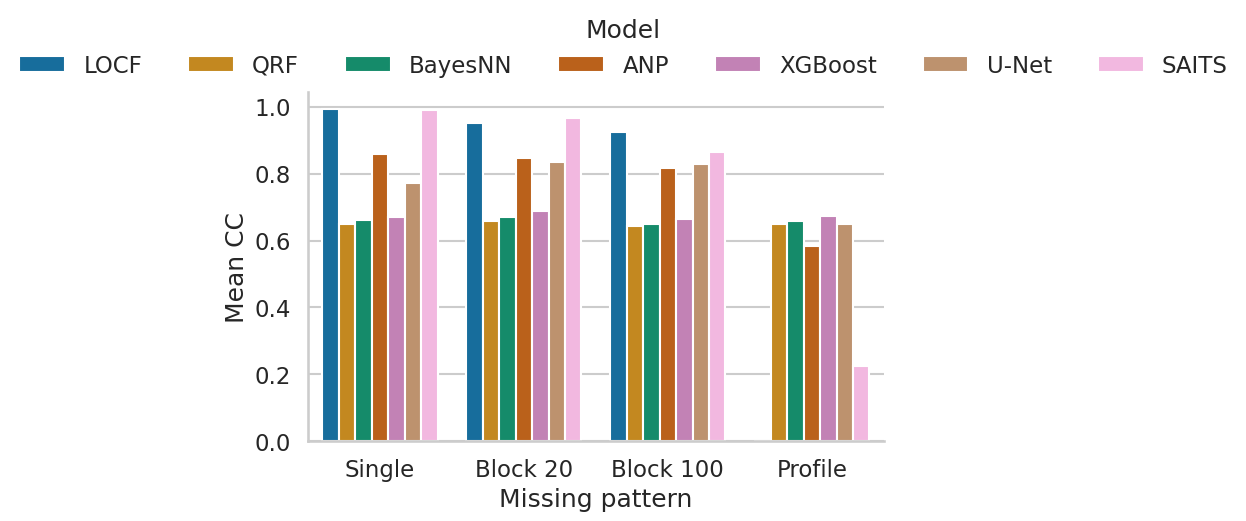

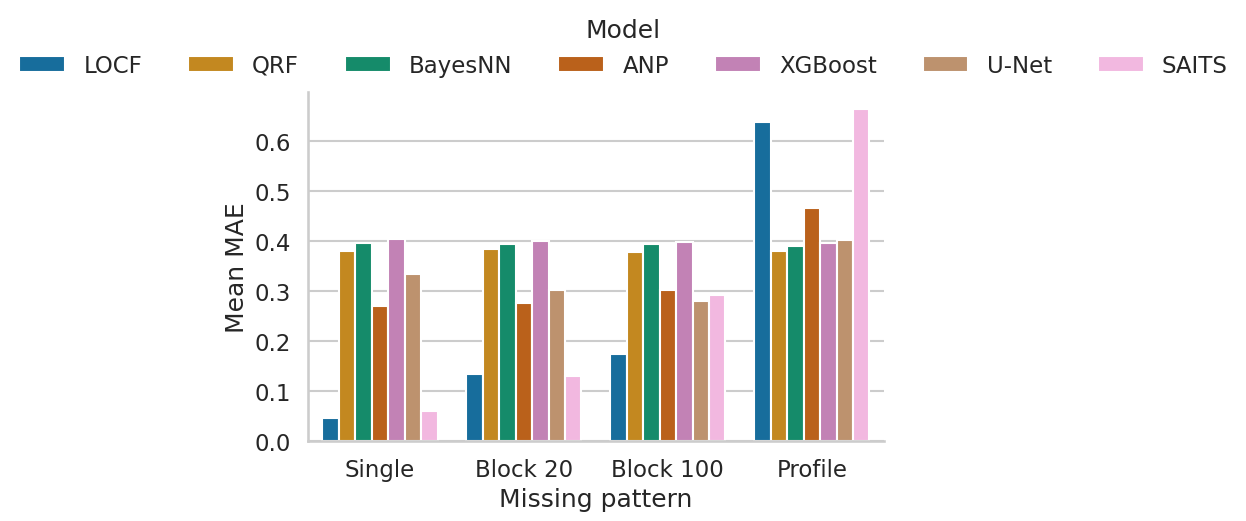

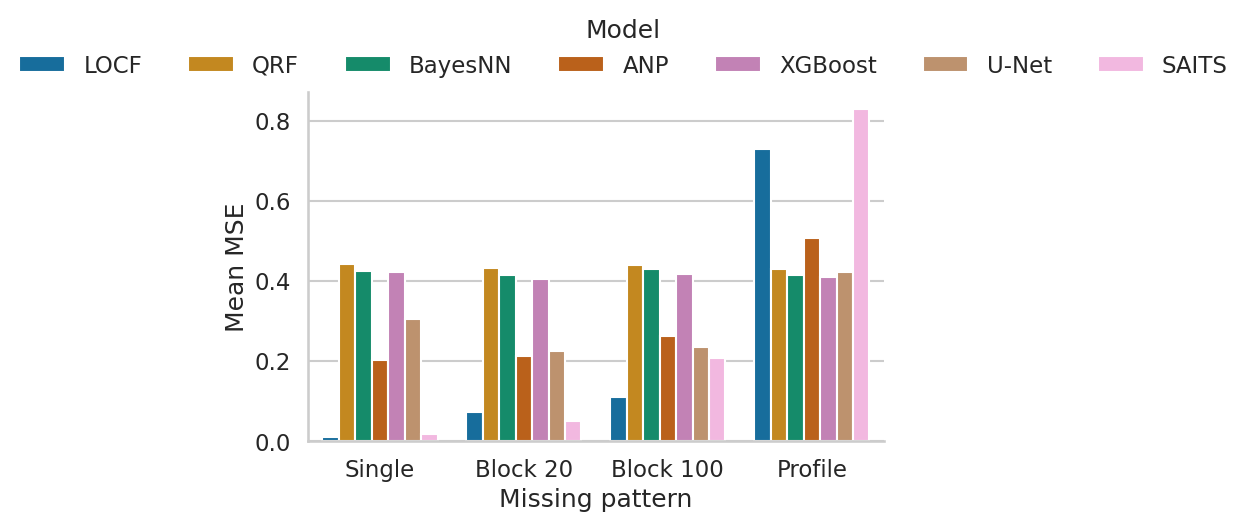

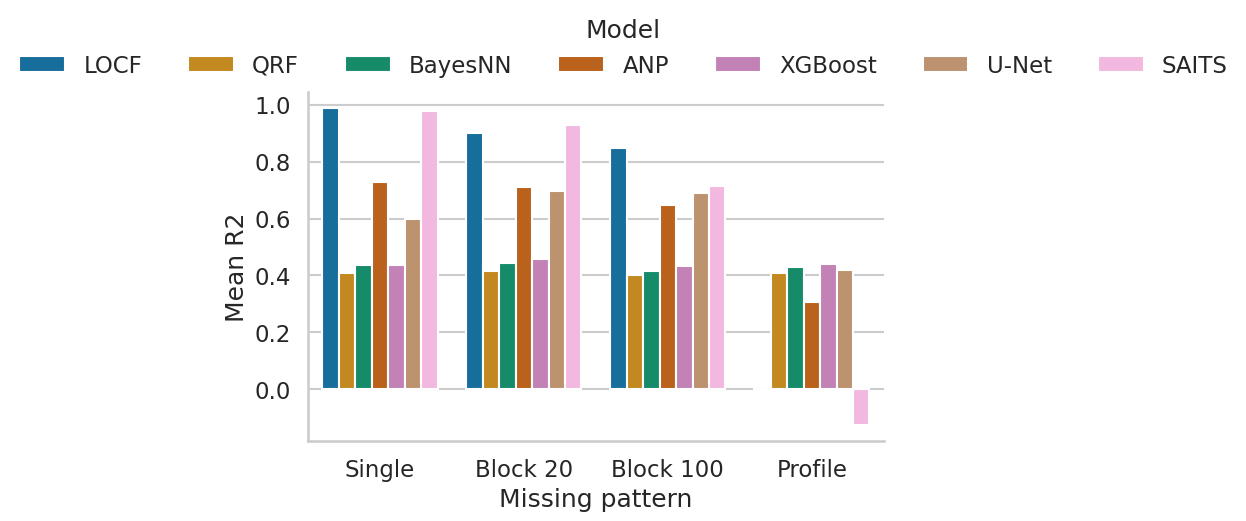

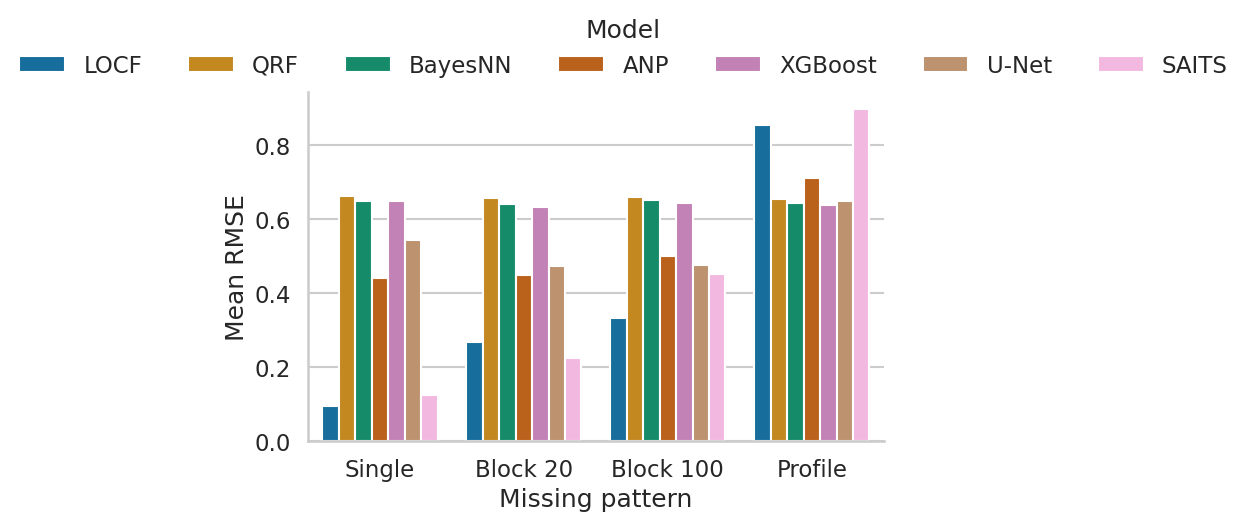

In [15]:
model_order = ["LOCF", "RF", "QRF", "BayesNN", "ANP", "XGBoost", "U-Net", "SAITS", "Transformer"]
model_order = [model for model in model_order if model in mean_metrics["Model"].unique()]
mode_order = ["Single", "Block 20", "Block 100", "Profile"]
palette = sns.color_palette("colorblind", n_colors=max(len(model_order), 1))

fig_dir = Path(OUTPUT_DIR) / "figs"
fig_dir.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="talk")

for metric in mean_metrics["Metric"].unique():
    metric_data = mean_metrics[mean_metrics["Metric"] == metric]
    grid = sns.catplot(
        data=metric_data, x="Mode", y="mean_value", hue="Model", col="Dataset",
        kind="bar", order=mode_order, hue_order=model_order,
        height=5, aspect=1.45, sharey=True, palette=palette, errorbar=None,
    )
    grid.set_axis_labels("Missing pattern", f"Mean {metric.upper()}")
    grid.set_titles("")
    sns.move_legend(grid, "upper center", bbox_to_anchor=(0.5, 1.08), ncol=max(len(model_order), 1))
    grid.savefig(fig_dir / f"{metric}.png", dpi=150, bbox_inches="tight")
    plt.show()


### 3.2.2 Predicted log curve from the best model


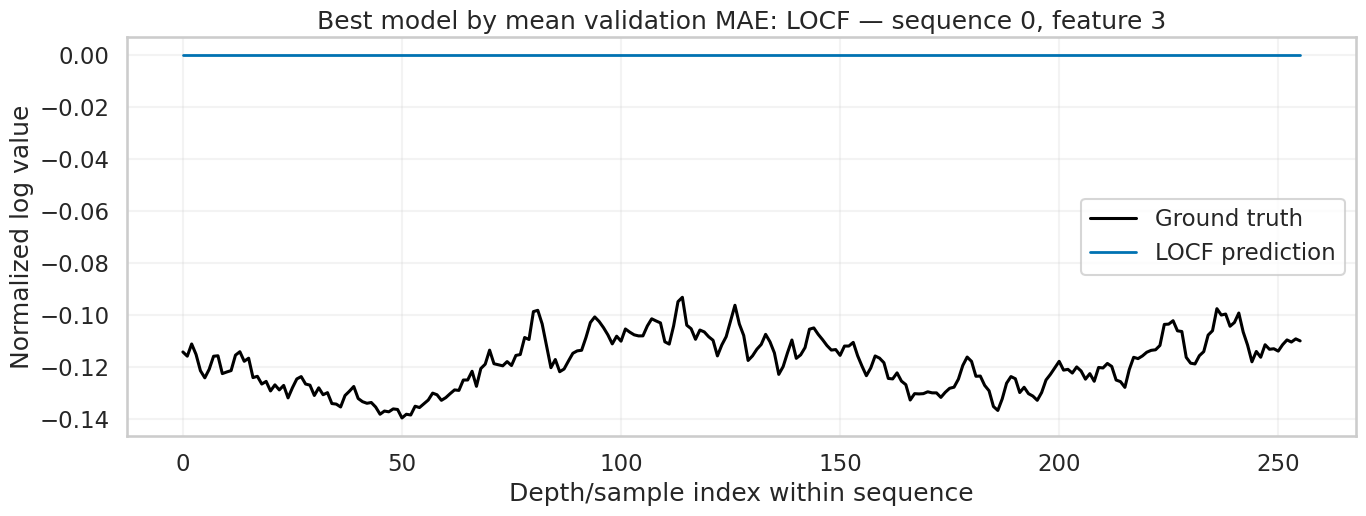

Selected LOCF; artifact: /kaggle/working/output/locf/predictions/locf_geolink_fold_0_profile.npz


In [16]:
import numpy as np

# Every completed model run saves compact point-prediction artifacts.
# Fall back to older QRF/BayesNN uncertainty artifacts when needed.
prediction_files = sorted(Path(OUTPUT_DIR).rglob("predictions/*.npz"))
if not prediction_files:
    prediction_files = sorted(Path(OUTPUT_DIR).rglob("uncertainty/*.npz"))
profile_prediction_files = [path for path in prediction_files if "profile" in path.stem]
candidate_files = profile_prediction_files or prediction_files

if not candidate_files:
    print("No saved predictions found. Run the model cells first.")
else:
    artifact_models = {path.name.split("_", 1)[0] for path in candidate_files}
    label_to_key = {
        "LOCF": "locf", "RF": "rf", "QRF": "qrf",
        "BayesNN": "bayesnn", "ANP": "anp", "XGBoost": "xgboost",
        "U-Net": "unet", "SAITS": "saits",
        "Transformer": "transformer", "mRNN": "mrnn", "SVM": "svm",
    }
    mae_ranking = (
        mean_metrics[mean_metrics["Metric"] == "mae"]
        .groupby("Model")["mean_value"].mean().sort_values()
    )
    eligible_labels = [
        label for label in mae_ranking.index
        if label_to_key.get(label) in artifact_models
    ]
    best_label = eligible_labels[0] if eligible_labels else sorted(artifact_models)[0].upper()
    best_key = label_to_key.get(best_label, best_label.lower())
    best_file = next(path for path in candidate_files if path.name.startswith(f"{best_key}_"))

    with np.load(best_file) as artifact:
        indices = artifact["indices"]
        truth_all = artifact["target"]
        prediction_all = artifact["prediction"]

    sequence_feature = indices[:, [0, 2]]
    unique_pairs, inverse, counts = np.unique(
        sequence_feature, axis=0, return_inverse=True, return_counts=True
    )
    pair_id = int(np.argmax(counts))
    selected = inverse == pair_id
    order = np.argsort(indices[selected, 1])
    depth = indices[selected, 1][order]
    truth = truth_all[selected][order]
    prediction = prediction_all[selected][order]
    sequence_id, feature_id = unique_pairs[pair_id]

    fig, axis = plt.subplots(figsize=(14, 5.5))
    axis.plot(depth, truth, color="black", linewidth=2.2, label="Ground truth")
    axis.plot(depth, prediction, color="#0072B2", linewidth=2.0, label=f"{best_label} prediction")
    axis.set(
        title=f"Best model by mean validation MAE: {best_label} — sequence {sequence_id}, feature {feature_id}",
        xlabel="Depth/sample index within sequence",
        ylabel="Normalized log value",
    )
    axis.legend(frameon=True)
    axis.grid(alpha=0.22)
    fig.tight_layout()
    fig.savefig(fig_dir / "best_model_log_prediction.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Selected {best_label}; artifact: {best_file}")


## 3.3 Visualize uncertainty results (QRF, BayesNN, and ANP)

In [17]:
uncertainty_pattern = re.compile(
    r"^validation-(picp|mpiw)-([^:]+):\s*(.+)$"
)
uncertainty_records = []

for log_path in sorted(Path(OUTPUT_DIR).rglob("*_*.log")):
    model, dataset = log_path.stem.split("_", 1)
    latest = {}
    for line in log_path.read_text(errors="replace").splitlines():
        match = uncertainty_pattern.match(line.strip())
        if match:
            latest[(match.group(1), match.group(2))] = [
                float(value) for value in match.group(3).split()
            ]
    for (metric, mode), values in latest.items():
        for fold, value in enumerate(values):
            uncertainty_records.append([model, dataset, metric, mode, fold, value])

uncertainty_df = pd.DataFrame(
    uncertainty_records,
    columns=["Model", "Dataset", "Metric", "Mode", "Fold", "Value"],
)
if uncertainty_df.empty:
    print("Run the QRF, BayesNN, or ANP cells to generate uncertainty results.")
else:
    uncertainty_df["Model"] = uncertainty_df["Model"].replace({"qrf": "QRF", "bayesnn": "BayesNN", "anp": "ANP"})
    uncertainty_df["Mode"] = uncertainty_df["Mode"].replace(mode_names)
    uncertainty_df["Dataset"] = uncertainty_df["Dataset"].replace(dataset_names)
    display(
        uncertainty_df.groupby(["Model", "Dataset", "Metric", "Mode"], as_index=False)
        .agg(mean_value=("Value", "mean"), std_value=("Value", "std"))
    )
    print("Raw lower/median/upper predictions are in each model's uncertainty/*.npz folder.")

,Model,Dataset,Metric,Mode,mean_value,std_value
0,ANP,Geolink,mpiw,Block 100,1.28228,0.285371
1,ANP,Geolink,mpiw,Block 20,1.29328,0.258027
2,ANP,Geolink,mpiw,Profile,1.35210,0.221096
3,ANP,Geolink,mpiw,Single,1.28806,0.275334
4,ANP,Geolink,picp,Block 100,0.92656,0.020830
5,ANP,Geolink,picp,Block 20,0.94668,0.014859
6,ANP,Geolink,picp,Profile,0.79854,0.079279
7,ANP,Geolink,picp,Single,0.94990,0.012396
8,BayesNN,Geolink,mpiw,Block 100,1.66664,0.032244
9,BayesNN,Geolink,mpiw,Block 20,1.68420,0.059152


Raw lower/median/upper predictions are in each model's uncertainty/*.npz folder.


### 3.3.1 Coverage and interval width

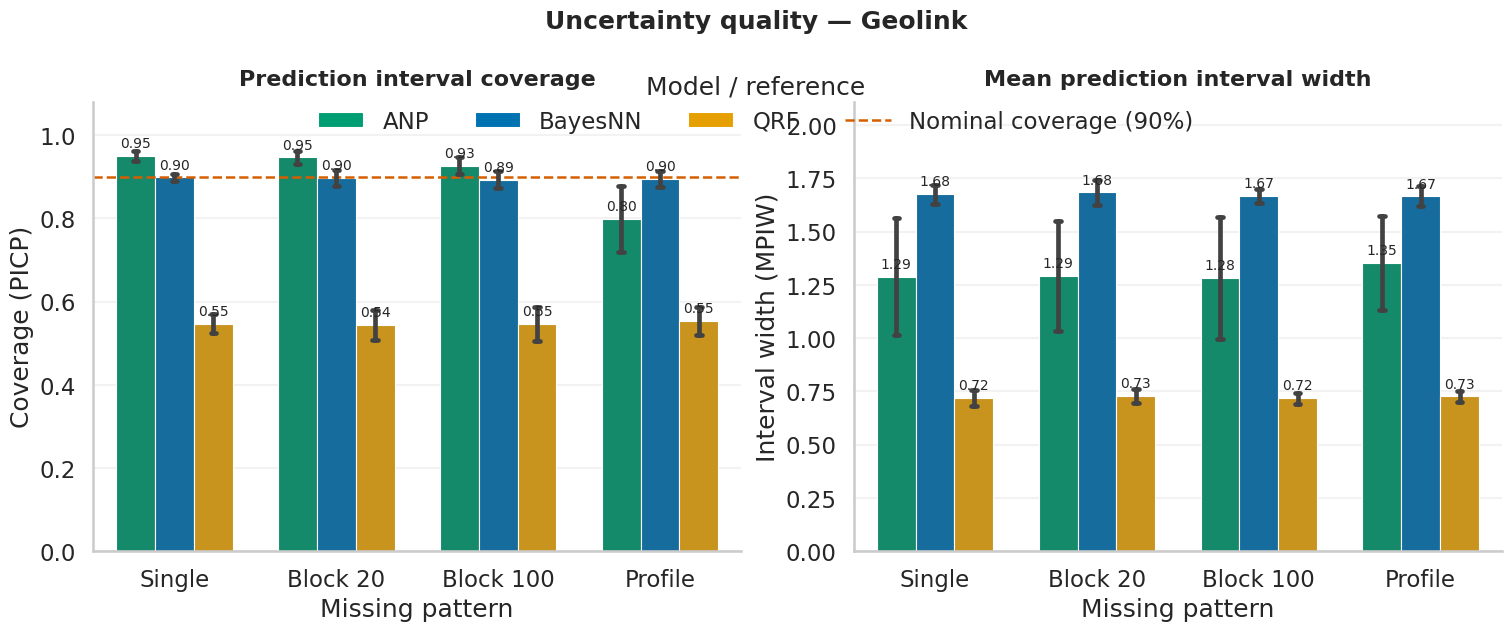

Saved: /kaggle/working/output/figs/uncertainty_summary_geolink.png


In [18]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

uncertainty_fig_dir = Path(OUTPUT_DIR) / "figs"
uncertainty_fig_dir.mkdir(parents=True, exist_ok=True)

if uncertainty_df.empty:
    print("No uncertainty metrics to plot. Run QRF, BayesNN, or ANP first.")
else:
    mode_order = ["Single", "Block 20", "Block 100", "Profile"]
    model_order_uncertainty = [
        model for model in ["ANP", "BayesNN", "QRF"]
        if model in uncertainty_df["Model"].unique()
    ]
    model_colors = {"ANP": "#009E73", "BayesNN": "#0072B2", "QRF": "#E69F00"}

    for dataset in uncertainty_df["Dataset"].unique():
        dataset_data = uncertainty_df[uncertainty_df["Dataset"] == dataset]
        fig, axes = plt.subplots(1, 2, figsize=(15, 5.6), constrained_layout=True)

        panels = [
            (axes[0], "picp", "Coverage (PICP)", "Prediction interval coverage"),
            (axes[1], "mpiw", "Interval width (MPIW)", "Mean prediction interval width"),
        ]
        for axis, metric, y_label, title in panels:
            metric_data = dataset_data[dataset_data["Metric"] == metric]
            if metric_data.empty:
                axis.set_visible(False)
                continue

            sns.barplot(
                data=metric_data,
                x="Mode",
                y="Value",
                hue="Model",
                order=mode_order,
                hue_order=model_order_uncertainty,
                palette=model_colors,
                errorbar="sd",
                capsize=0.10,
                width=0.72,
                edgecolor="white",
                linewidth=0.8,
                ax=axis,
            )
            if axis.legend_ is not None:
                axis.legend_.remove()

            for container in axis.containers:
                axis.bar_label(container, fmt="%.2f", padding=4, fontsize=10)

            axis.set_title(title, fontsize=16, pad=12, weight="semibold")
            axis.set_xlabel("Missing pattern")
            axis.set_ylabel(y_label)
            axis.grid(axis="y", alpha=0.24)
            axis.grid(axis="x", visible=False)
            sns.despine(ax=axis)

            if metric == "picp":
                axis.axhline(
                    0.90, color="#D55E00", linestyle="--", linewidth=1.8,
                    zorder=1,
                )
                axis.set_ylim(0, 1.08)
            else:
                upper = metric_data["Value"].max()
                axis.set_ylim(0, max(1.0, upper * 1.18))

        legend_handles = [
            Patch(facecolor=model_colors[model], edgecolor="white", label=model)
            for model in model_order_uncertainty
        ]
        legend_handles.append(
            Line2D([0], [0], color="#D55E00", linestyle="--", linewidth=1.8,
                   label="Nominal coverage (90%)")
        )
        fig.legend(
            handles=legend_handles,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.02),
            ncol=len(legend_handles),
            frameon=False,
            title="Model / reference",
        )
        fig.suptitle(
            f"Uncertainty quality — {dataset}",
            fontsize=18, weight="bold", y=1.10,
        )

        safe_dataset = str(dataset).lower().replace(" ", "_")
        output_path = uncertainty_fig_dir / f"uncertainty_summary_{safe_dataset}.png"
        fig.savefig(output_path, dpi=180, bbox_inches="tight")
        plt.show()
        print(f"Saved: {output_path}")


### 3.3.2 BayesNN predictive interval along a log sequence


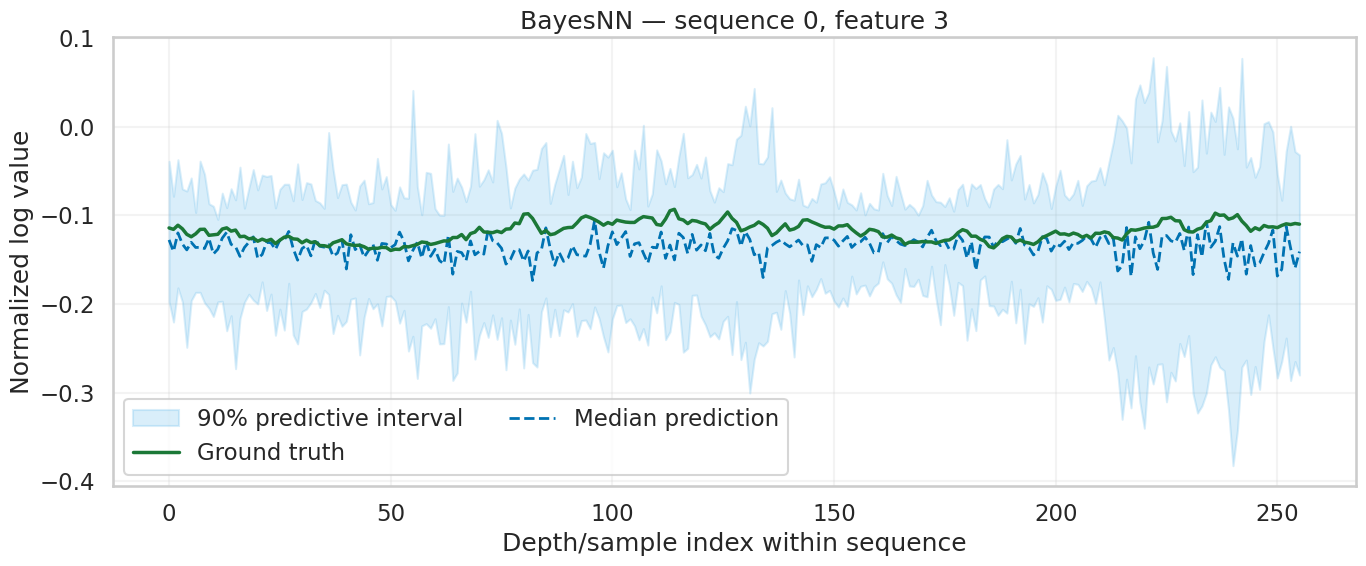

Displayed: /kaggle/working/output/bayesnn/uncertainty/bayesnn_geolink_fold_0_profile.npz


In [19]:
import numpy as np

# Set this to a specific .npz path to inspect another BayesNN fold or missing pattern.
BAYESNN_FILE = None
available_files = sorted(Path(OUTPUT_DIR).rglob("uncertainty/bayesnn_*.npz"))
profile_files = [path for path in available_files if "profile" in path.stem]

if BAYESNN_FILE is not None:
    selected_file = Path(BAYESNN_FILE)
elif profile_files:
    selected_file = profile_files[0]
elif available_files:
    selected_file = available_files[0]
else:
    selected_file = None

if selected_file is None:
    print("No BayesNN uncertainty artifact found. Run the BayesNN cell first.")
else:
    with np.load(selected_file) as artifact:
        indices = artifact["indices"]
        target = artifact["target"]
        prediction = artifact["prediction"]
        lower = artifact["lower"]
        upper = artifact["upper"]

    # Select the sequence/feature pair with the most masked depth samples.
    sequence_feature = indices[:, [0, 2]]
    unique_pairs, inverse, counts = np.unique(
        sequence_feature, axis=0, return_inverse=True, return_counts=True
    )
    pair_id = int(np.argmax(counts))
    selected = inverse == pair_id
    depth_order = np.argsort(indices[selected, 1])
    depth = indices[selected, 1][depth_order]
    truth = target[selected][depth_order]
    median = prediction[selected][depth_order]
    q_low = lower[selected][depth_order]
    q_high = upper[selected][depth_order]
    covered = (truth >= q_low) & (truth <= q_high)
    sequence_id, feature_id = unique_pairs[pair_id]

    fig, axis = plt.subplots(figsize=(14, 6))
    axis.fill_between(
        depth, q_low, q_high, color="#56B4E9", alpha=0.22,
        label="90% predictive interval",
    )
    axis.plot(
        depth, truth, color="#1B7837", linestyle="-", linewidth=2.5,
        label="Ground truth", zorder=4,
    )
    axis.plot(
        depth, median, color="#0072B2", linestyle="--", linewidth=2.0,
        label="Median prediction", zorder=3,
    )
    if np.any(~covered):
        axis.scatter(
            depth[~covered], truth[~covered], color="#D55E00", marker="x", s=42,
            label="Ground truth outside interval", zorder=5,
        )
    axis.set(
        title=f"BayesNN — sequence {sequence_id}, feature {feature_id}",
        xlabel="Depth/sample index within sequence",
        ylabel="Normalized log value",
    )
    axis.legend(ncol=2, frameon=True)
    axis.grid(alpha=0.22)
    fig.tight_layout()
    fig.savefig(uncertainty_fig_dir / f"{selected_file.stem}_interval.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Displayed: {selected_file}")
